In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
df=pd.read_csv('set2_dbscan_customer.csv')

In [13]:
print(df.isnull().sum())
df.fillna(df.mean(), inplace=True)
features = df[['Income', 'Spending_Score', 'Age', 'Credit_Usage']]



Income            0
Spending_Score    0
Age               0
Credit_Usage      0
dtype: int64


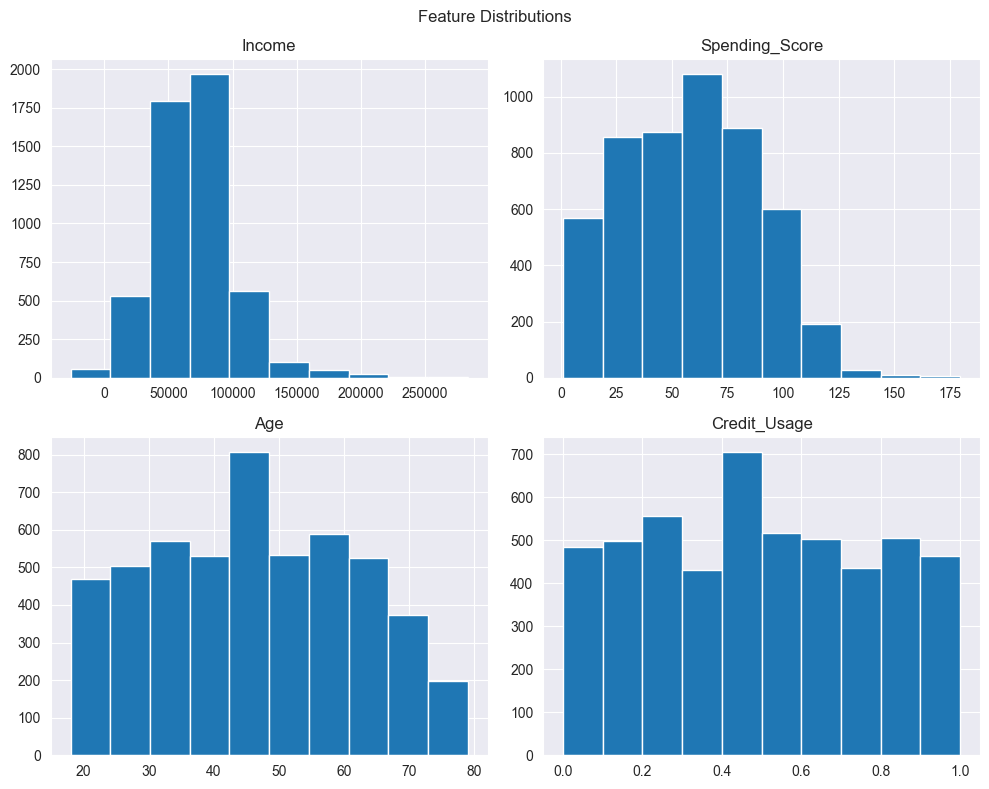

In [14]:

df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

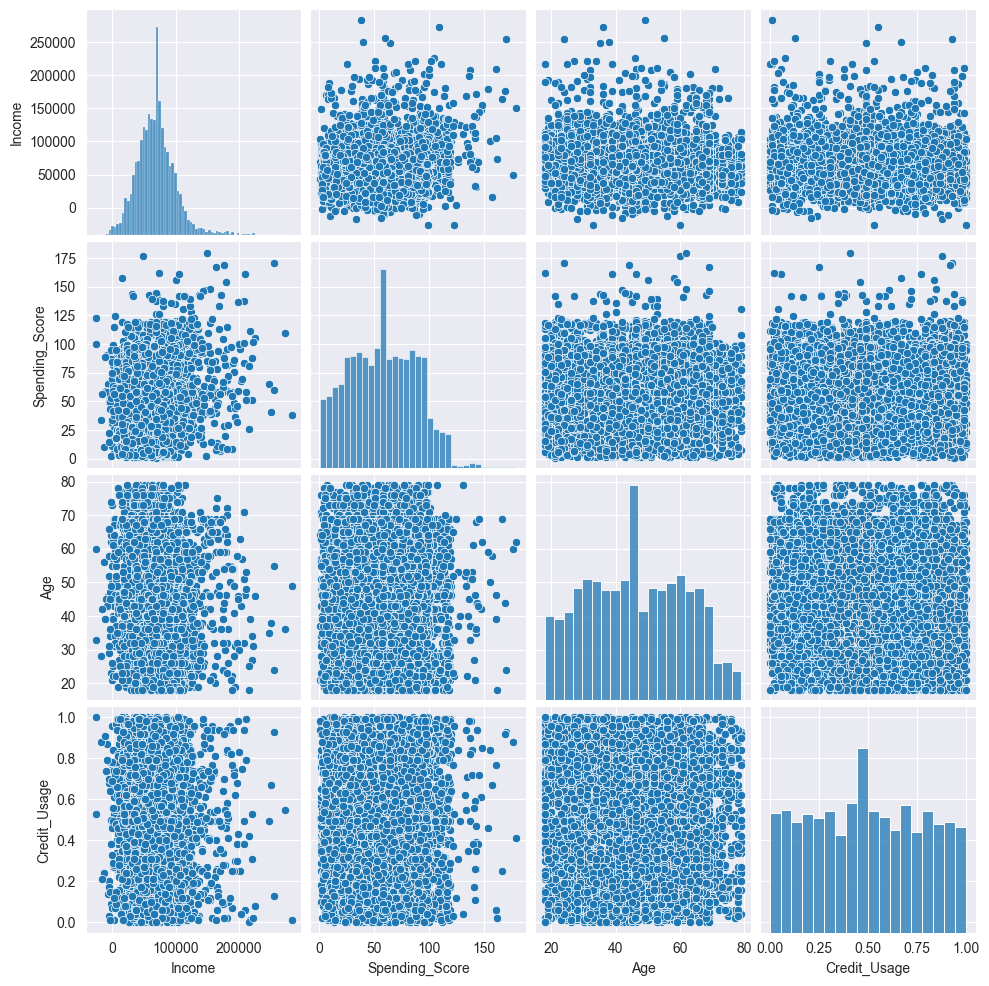

In [15]:
sns.pairplot(df)
plt.show()



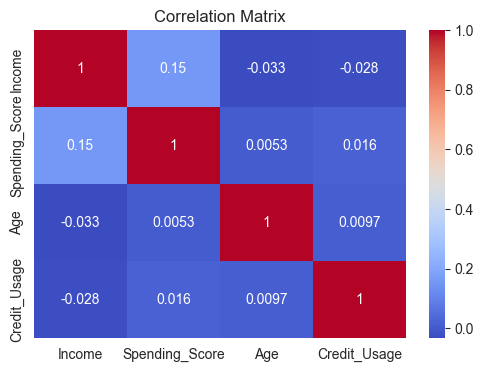

In [6]:
# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [16]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


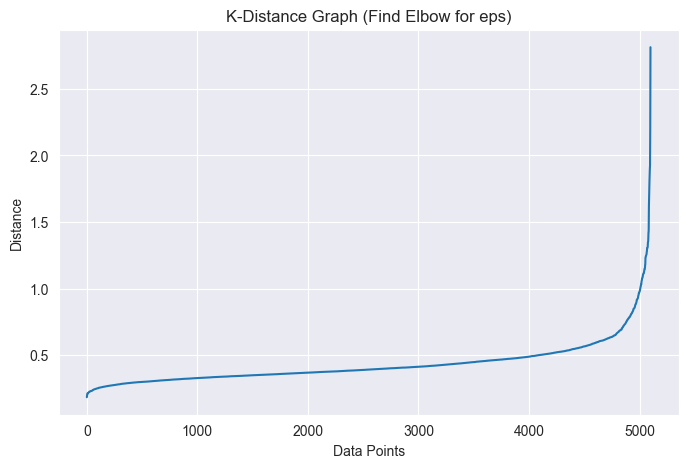

In [12]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Graph (Find Elbow for eps)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [17]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X_scaled)
df['Cluster'] = labels
print("\n--- Cluster Distribution ---")
print(df['Cluster'].value_counts())


--- Cluster Distribution ---
Cluster
 0    4986
-1     110
 1       4
Name: count, dtype: int64


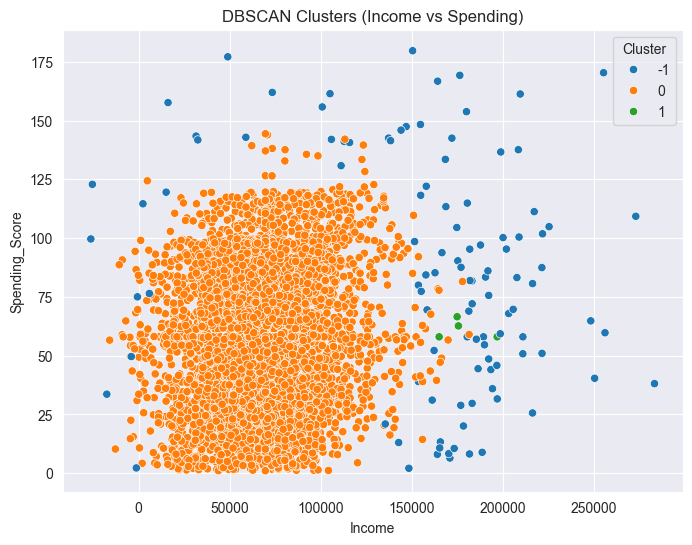

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Income'],
    y=df['Spending_Score'],
    hue=df['Cluster'],
    palette='tab10'
)
plt.title("DBSCAN Clusters (Income vs Spending)")
plt.show()

g

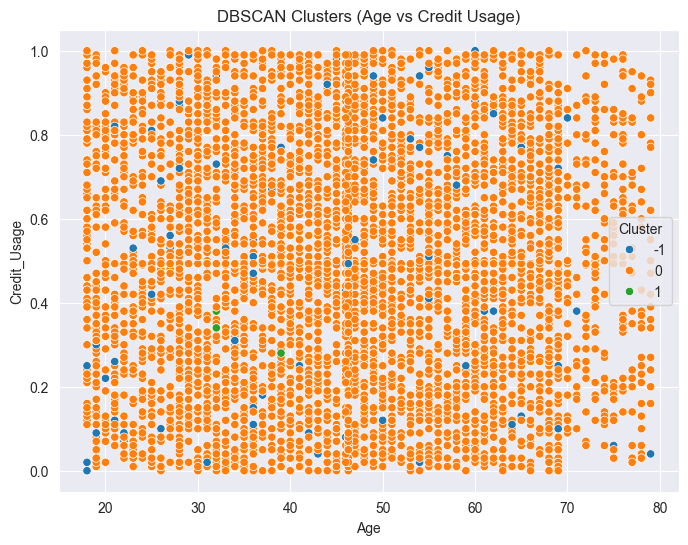

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Age'],y=df['Credit_Usage'],hue=df['Cluster'],palette='tab10')
plt.title("DBSCAN Clusters (Age vs Credit Usage)")
plt.show()

In [20]:
print("\n--- Cluster Means (Interpretation Help) ---")
print(df.groupby('Cluster').mean())


print("\n--- Key Insights ---")



--- Cluster Means (Interpretation Help) ---
                Income  Spending_Score        Age  Credit_Usage
Cluster                                                        
-1       158370.285727       87.148444  44.107606      0.480655
 0        67515.788483       57.326626  46.337659      0.493430
 1       178024.480000       61.273969  32.750000      0.315000

--- Key Insights ---
